<a href="https://colab.research.google.com/github/heyshravan/Animuthyalu/blob/main/ML_EXPERIMENT_2_House_Price_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

In [ ]:
df = pd.read_csv("/content/train_1.csv")

print(df.head())

   Id  MSSubClass MSZoning  LotFrontage  LotArea Street Alley LotShape  \
0   1          60       RL         65.0     8450   Pave   NaN      Reg   
1   2          20       RL         80.0     9600   Pave   NaN      Reg   
2   3          60       RL         68.0    11250   Pave   NaN      IR1   
3   4          70       RL         60.0     9550   Pave   NaN      IR1   
4   5          60       RL         84.0    14260   Pave   NaN      IR1   

  LandContour Utilities  ... PoolArea PoolQC Fence MiscFeature MiscVal MoSold  \
0         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      2   
1         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      5   
2         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      9   
3         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      2   
4         Lvl    AllPub  ...        0    NaN   NaN         NaN       0     12   

  YrSold  SaleType  SaleCondition  SalePrice  
0   2008        WD   

In [ ]:
print(df.info())
print(df.shape)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [ ]:
num_cols = df.select_dtypes(include=np.number).columns

for col in num_cols:
    df[col].fillna(df[col].median(), inplace=True)

/tmp/ipykernel_1141/3551297251.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)


In [ ]:
cat_cols = df.select_dtypes(include="object").columns

for col in cat_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)

/tmp/ipykernel_1141/719105301.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mode()[0], inplace=True)


In [ ]:
label = LabelEncoder()

for col in cat_cols:
    df[col] = label.fit_transform(df[col])

In [ ]:
features = [
    "GrLivArea",
    "BedroomAbvGr",
    "FullBath",
    "GarageCars",
    "GarageArea",
    "OverallQual",
    "YearBuilt",
    "LotArea",
    "Neighborhood"
]

X = df[features]
y = df["SalePrice"]

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training Set:", X_train.shape)
print("Testing Set:", X_test.shape)

Training Set: (1168, 9)
Testing Set: (292, 9)


In [ ]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
lr = LinearRegression()

lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

print("Intercept")
print(lr.intercept_)

print("\nCoefficients")

for feature, coef in zip(features, lr.coef_):
    print(feature, ":", coef)

Intercept
181441.54195205483

Coefficients
GrLivArea : 31255.599648709325
BedroomAbvGr : -6049.260455333064
FullBath : -2730.2582336299783
GarageCars : 7314.507127867418
GarageArea : 4058.372769733081
OverallQual : 29501.388042330662
YearBuilt : 12709.347442626895
LotArea : 8089.236360188456
Neighborhood : 2804.944174723533


In [ ]:
print("R2 :", r2_score(y_test, y_pred_lr))
print("MAE :", mean_absolute_error(y_test, y_pred_lr))
print("RMSE :", np.sqrt(mean_squared_error(y_test, y_pred_lr)))

R2 : 0.7857569470322299
MAE : 26023.061610630546
RMSE : 40537.810792967924


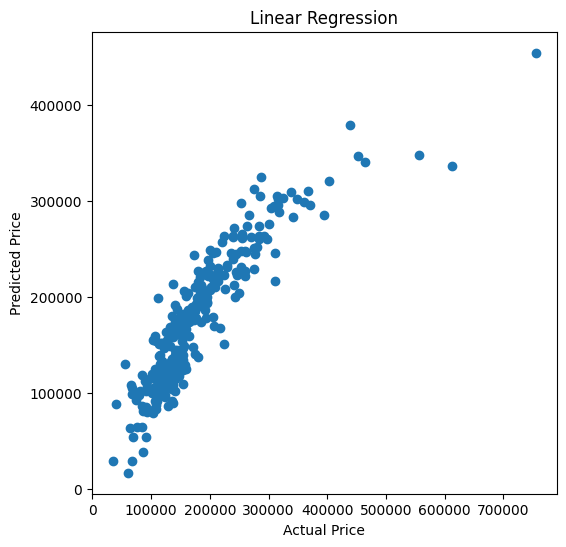

In [ ]:
plt.figure(figsize=(6, 6))

plt.scatter(y_test, y_pred_lr)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Linear Regression")

plt.show()

In [ ]:
poly = PolynomialFeatures(degree=2)

X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

poly_model = LinearRegression()

poly_model.fit(X_train_poly, y_train)

poly_pred = poly_model.predict(X_test_poly)

In [ ]:
ridge = Ridge(alpha=1)

ridge.fit(X_train, y_train)

ridge_pred = ridge.predict(X_test)

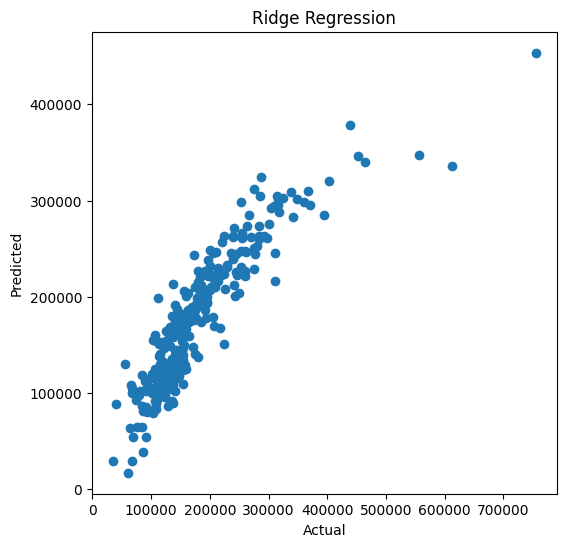

In [ ]:
plt.figure(figsize=(6, 6))

plt.scatter(y_test, ridge_pred)

plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Ridge Regression")

plt.show()

In [ ]:
lasso = Lasso(alpha=0.5)

lasso.fit(X_train, y_train)

lasso_pred = lasso.predict(X_test)

print("Intercept")
print(lasso.intercept_)

print("\nCoefficients")
print(lasso.coef_)

Intercept
181441.54195205483

Coefficients
[31253.75712767 -6048.5125505  -2728.39711403  7313.97740286
  4058.93952298 29501.578464   12708.32205405  8088.91996189
  2804.48976403]


In [ ]:
print("R2 :", r2_score(y_test, lasso_pred))
print("MAE :", mean_absolute_error(y_test, lasso_pred))
print("RMSE :", np.sqrt(mean_squared_error(y_test, lasso_pred)))

R2 : 0.7857547004748212
MAE : 26022.989083795852
RMSE : 40538.02333260262


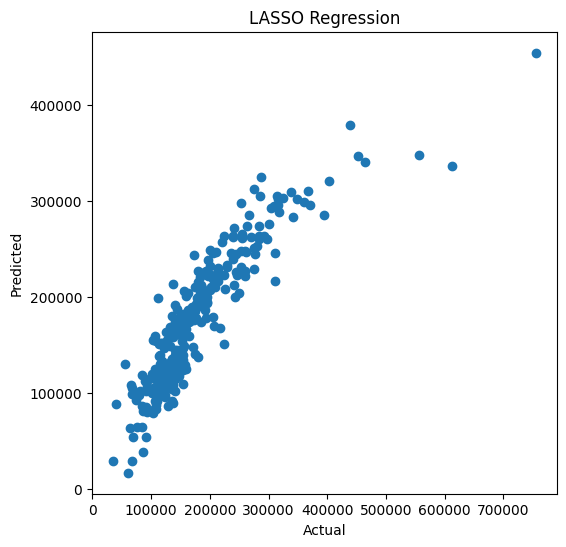

In [ ]:
plt.figure(figsize=(6, 6))

plt.scatter(y_test, lasso_pred)

plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("LASSO Regression")

plt.show()

In [ ]:
results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Polynomial Regression",
        "Ridge Regression",
        "LASSO Regression"
    ],

    "R2 Score": [
        r2_score(y_test, y_pred_lr),
        r2_score(y_test, poly_pred),
        r2_score(y_test, ridge_pred),
        r2_score(y_test, lasso_pred)
    ],

    "MAE": [
        mean_absolute_error(y_test, y_pred_lr),
        mean_absolute_error(y_test, poly_pred),
        mean_absolute_error(y_test, ridge_pred),
        mean_absolute_error(y_test, lasso_pred)
    ],

    "RMSE": [
        np.sqrt(mean_squared_error(y_test, y_pred_lr)),
        np.sqrt(mean_squared_error(y_test, poly_pred)),
        np.sqrt(mean_squared_error(y_test, ridge_pred)),
        np.sqrt(mean_squared_error(y_test, lasso_pred))
    ]
})

print(results)

                   Model  R2 Score           MAE          RMSE
0      Linear Regression  0.785757  26023.061611  40537.810793
1  Polynomial Regression  0.859483  21638.204872  32830.061183
2       Ridge Regression  0.785660  26019.602353  40546.984796
3       LASSO Regression  0.785755  26022.989084  40538.023333


In [ ]:
print("Result:")
print("Different regression models were successfully implemented")
print("for house price prediction.")

print("Polynomial Regression achieved the highest R2 Score")
print("among the compared models in the given experiment.")

Result:
Different regression models were successfully implemented
for house price prediction.
Polynomial Regression achieved the highest R2 Score
among the compared models in the given experiment.
